# Week 2 — Notebook 3: Comparative Analysis (Bonus)

This notebook contains analysis questions that require you to **write code and explain your findings**.

For each question:
1. Write your code in the empty cell below the question
2. Add a short written answer (2–4 sentences) in a markdown cell after your output

You may load processed CSVs from `data/processed/` or recompute indicators directly from `data/raw/`.

> Charts must have titles, axis labels, and legends. Written answers must reference specific dates or numbers from your output.

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

def safe_symbol(s):
    return s.replace('^','').replace('.',  '_').replace('=','_').replace('-','_')

def load_features(symbol):
    return pd.read_csv(PROCESSED_DIR / f'{safe_symbol(symbol)}_features.csv',
                       parse_dates=['date'], index_col='date')

print('Setup done.')

Setup done.


In [18]:
import yfinance as yf
from pathlib import Path

RAW_DIR = Path('data/raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)

symbols = ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'SPY',
           'BTC-USD', 'ETH-USD', 'BNB-USD',
           'RELIANCE.NS', 'TCS.NS', 'INFY.NS',
           'HDFCBANK.NS', '^NSEI']

for sym in symbols:
    try:
        df = yf.download(sym, start='2014-01-01',
                        auto_adjust=True, progress=False)

        # Fix for newer yfinance version
        if isinstance(df.columns[0], tuple):
            df.columns = [c[0].lower() for c in df.columns]
        else:
            df.columns = [c.lower() for c in df.columns]

        df.index.name = 'date'
        df.reset_index(inplace=True)

        safe = sym.replace('^','').replace('.','_').replace('-','_')
        df.to_csv(RAW_DIR / f'{safe}.csv', index=False)
        print(f' {sym} → {len(df)} rows')
    except Exception as e:
        print(f'{sym}: {e}')

 AAPL → 3123 rows
 MSFT → 3123 rows
 NVDA → 3123 rows
 TSLA → 3123 rows
 SPY → 3123 rows
 BTC-USD → 4279 rows
 ETH-USD → 3130 rows
 BNB-USD → 3130 rows
 RELIANCE.NS → 3065 rows
 TCS.NS → 3065 rows
 INFY.NS → 3065 rows
 HDFCBANK.NS → 3065 rows
 ^NSEI → 3050 rows


In [21]:
from pathlib import Path

# Create both folders
Path('data/raw').mkdir(parents=True, exist_ok=True)
Path('data/processed').mkdir(parents=True, exist_ok=True)

print(' Folders created!')
print('raw exists:', Path('data/raw').exists())
print('processed exists:', Path('data/processed').exists())

 Folders created!
raw exists: True
processed exists: True


In [22]:

for csv_path in RAW_DIR.glob('*.csv'):
    sym = csv_path.stem
    try:
        raw = pd.read_csv(csv_path, parse_dates=['date'])
        raw = raw.sort_values('date').set_index('date')
        raw['volume'] = raw['volume'].replace(0, np.nan)
        rows_raw = len(raw)
        c = raw['close']; h = raw['high']
        l = raw['low'];   v = raw['volume']
        raw['return_1']     = c.pct_change(1)
        raw['return_5']     = c.pct_change(5)
        raw['log_return_1'] = np.log(c / c.shift(1))
        sma20 = c.rolling(20).mean()
        sma50 = c.rolling(50).mean()
        raw['sma_ratio_20'] = c / sma20 - 1
        raw['sma_ratio_50'] = c / sma50 - 1
        ema12 = c.ewm(span=12, adjust=False).mean()
        ema20 = c.ewm(span=20, adjust=False).mean()
        ema26 = c.ewm(span=26, adjust=False).mean()
        raw['ema_ratio_20'] = c / ema20 - 1
        delta    = c.diff()
        gain     = delta.where(delta > 0, 0)
        loss     = -delta.where(delta < 0, 0)
        avg_gain = gain.ewm(com=13, adjust=False).mean()
        avg_loss = loss.ewm(com=13, adjust=False).mean()
        rs       = avg_gain / avg_loss
        raw['rsi_14'] = (100 - (100 / (1 + rs))) / 100
        raw['macd']        = ema12 - ema26
        raw['macd_signal'] = raw['macd'].ewm(span=9, adjust=False).mean()
        raw['macd_hist']   = raw['macd'] - raw['macd_signal']
        raw['roc_5']  = c.pct_change(5)
        raw['roc_10'] = c.pct_change(10)
        std20    = c.rolling(20).std()
        bb_upper = sma20 + 2 * std20
        bb_lower = sma20 - 2 * std20
        raw['bb_width'] = (bb_upper - bb_lower) / c
        raw['bb_pct_b'] = ((c - bb_lower) / (bb_upper - bb_lower)).clip(0, 1)
        prev_close = c.shift(1)
        tr = pd.concat([
            h - l,
            (h - prev_close).abs(),
            (l - prev_close).abs()
        ], axis=1).max(axis=1)
        raw['atr_ratio'] = tr.ewm(com=13, adjust=False).mean() / c
        low14  = l.rolling(14).min()
        high14 = h.rolling(14).max()
        raw['stoch_k'] = (c - low14) / (high14 - low14)
        raw['stoch_d'] = raw['stoch_k'].rolling(3).mean()
        obv = (np.sign(c.diff()) * v).fillna(0).cumsum()
        raw['obv_change'] = obv.diff() / obv.shift(1).abs()
        tp = (h + l + c) / 3
        raw['vwap']       = (tp * v).rolling(20).sum() / v.rolling(20).sum()
        raw['vwap_ratio'] = c / raw['vwap'] - 1
        raw['future_return']    = c.shift(-1) / c - 1
        raw['target_direction'] = (raw['future_return'] > 0).astype(int)
        FEATURE_COLUMNS = [
            'return_1', 'return_5', 'log_return_1',
            'sma_ratio_20', 'sma_ratio_50', 'ema_ratio_20',
            'rsi_14', 'macd', 'macd_signal', 'macd_hist',
            'roc_5', 'roc_10', 'bb_width', 'bb_pct_b',
            'atr_ratio', 'stoch_k', 'stoch_d',
            'obv_change', 'vwap_ratio'

        ]
        required = FEATURE_COLUMNS + ['future_return', 'target_direction']
        raw.replace([np.inf, -np.inf], np.nan, inplace=True)
        processed = raw.dropna(subset=required).reset_index()
        out_path = PROCESSED_DIR / f'{sym}_features.csv'
        processed.to_csv(out_path, index=False)
        print(f' {sym} saved!')
    except Exception as e:
        print(f' {sym}: {e}')

 BNB_USD saved!
 TCS_NS saved!
 TSLA saved!
 HDFCBANK_NS saved!
 RELIANCE_NS saved!
 MSFT saved!
 NVDA saved!
 AAPL saved!
 NSEI saved!
 SPY saved!
 ETH_USD saved!
 BTC_USD saved!
 INFY_NS saved!


---

## Q1 — Which US stock had the highest average SMA-20 over 2020–2024?

Load the processed features for `AAPL`, `MSFT`, `NVDA`, `TSLA`, and `SPY`.
Filter to **2020-01-01 → 2024-12-31**.
For each symbol, compute the mean of its `sma_ratio_20` over that period (not the raw SMA value — the ratio tells you how far above/below average each stock typically trades).
Display results as a **horizontal bar chart**, sorted from highest to lowest.

**Answer in a markdown cell:** Which stock was most consistently above its 20-day average? What does a persistently positive sma_ratio suggest about its trend?

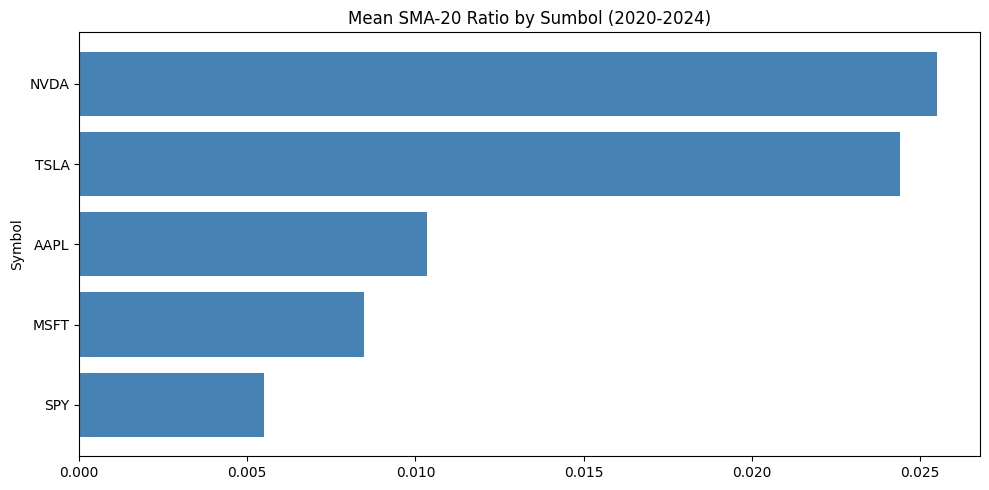

SPY     0.005492
MSFT    0.008461
AAPL    0.010335
TSLA    0.024395
NVDA    0.025510
dtype: float64


In [23]:
# Your code here

symbols=['AAPL','MSFT','NVDA','TSLA','SPY']
results={}
for sym in symbols:
  df=load_features(sym)
  df=df['2020-01-01':'2024-12-31']
  results[sym]=df['sma_ratio_20'].mean()

sma_means=pd.Series(results).sort_values(ascending=True) #results is a dictionary, pd.Series(results) converts dictionary to Series.

plt.figure(figsize=(10,5))
plt.barh(sma_means.index,sma_means.values,color='steelblue') #sma_means.index- Y axis → symbol names, sma_means.values- X axis -sma_ratio_20 mean values.
plt.title('Mean SMA-20 Ratio by Sumbol (2020-2024)')
plt.ylabel('Symbol')
plt.tight_layout()
plt.show()

print(sma_means)



NVDA was very much consistent during this time of 2020-2024,close price is always ahead of 20 days previous moving average . It is beneficial and safe to buy the stocks of NVDA during this time.

---

## Q2 — Side-by-side RSI comparison: one Indian stock, one US stock, one crypto

Choose one symbol from each group:
- India: `RELIANCE.NS` or `TCS.NS`
- US: `AAPL`, `MSFT`, or `NVDA`
- Crypto: `BTC-USD` or `ETH-USD`

Plot their `rsi_14` in a **3-row subplot** sharing the x-axis, covering the most recent **two full years** of data.
Draw dashed lines at 0.70 (overbought) and 0.30 (oversold) on each panel.

**Answer in a markdown cell:** Which asset class spends the most time in extreme RSI territory (above 0.70 or below 0.30)? Give a possible reason.

/tmp/ipykernel_6191/1949291063.py:14: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df=df.last('730D')
/tmp/ipykernel_6191/1949291063.py:14: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df=df.last('730D')
/tmp/ipykernel_6191/1949291063.py:14: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df=df.last('730D')


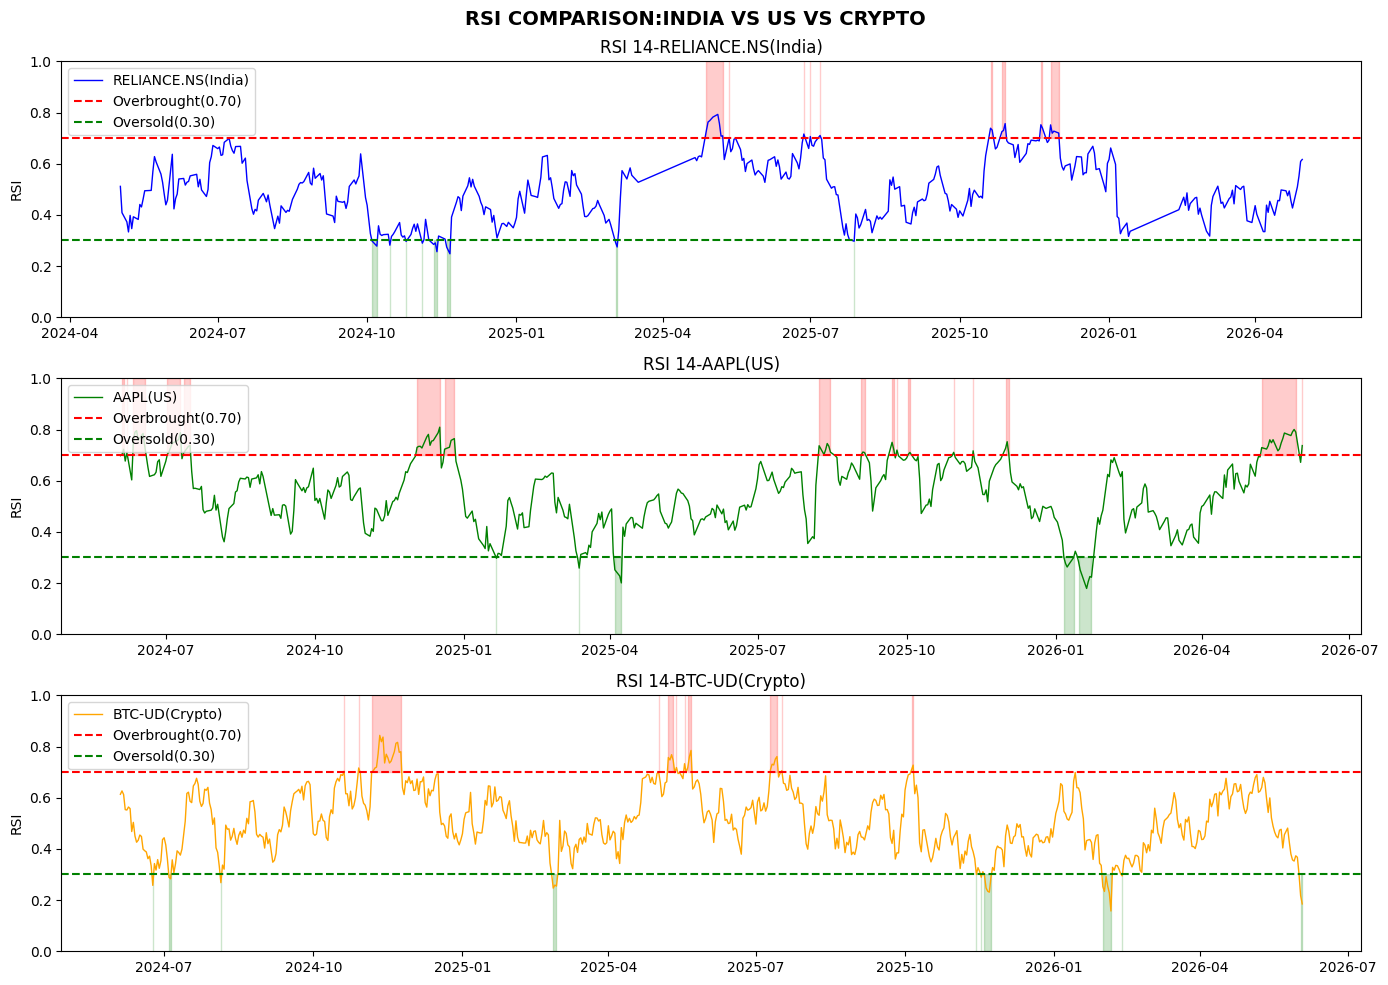

In [26]:
from matplotlib import colors
# Your code here
india='RELIANCE.NS'
us='AAPL'
crypto='BTC-USD'

symbols_q2=[india,us,crypto]
labels=['RELIANCE.NS(India)','AAPL(US)','BTC-UD(Crypto)']
colors=['blue','green','orange']

fig,axes=plt.subplots(3,1,figsize=(14,10),sharex=False)
for i,(sym,label,color) in enumerate(zip(symbols_q2,labels,colors)): # enumerate(zip(...)) gives:(0, ('RELIANCE.NS', 'Reliance.NS(India)','blue'))
  df=load_features(sym) #Reliance.NS ->Reliance_NS
  df=df.last('730D')

  axes[i].plot(df.index,df['rsi_14'],
               label=label,color=color,linewidth=1)

  axes[i].axhline(0.70,color='red',
                  linestyle='--',label='Overbrought(0.70)')
  axes[i].axhline(0.30,color='green',
                  linestyle='--',label='Oversold(0.30)')
  axes[i].fill_between(df.index,0.70,1.0,
                       where=df['rsi_14']>0.70,
                       color='red',alpha=0.2)
  axes[i].fill_between(df.index,0.0,0.30,
                       where=df['rsi_14']<0.30,
                       color='green',alpha=0.2)
  axes[i].set_title(f'RSI 14-{label}')
  axes[i].set_ylabel('RSI')
  axes[i].legend(loc='upper left')
  axes[i].set_ylim(0,1)

plt.suptitle('RSI COMPARISON:INDIA VS US VS CRYPTO',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


Reliance is most of the time stable except 2024-10 to 2025-01 where rsi<0.3 (OVERSOLD region - Time to buy), and its rsi>0.7 around 2025-05 or 2025-06 and 2025-12.
BTC-USD has most of it timeperiod at rsi=0.7 means overbrought region.
AAPL  is most on the rsi>0.7 side as compared to rsi<0.3 side. Remaining time the stock has performed consistent.

---

## Q3 — MACD histogram comparison: AAPL vs MSFT vs NVDA

Plot the `macd_hist` column for all three symbols in a **3-row subplot** (shared x-axis, last two years).
Colour bars **green** when positive and **red** when negative so crossovers are visually clear.

Then count the number of histogram sign changes per symbol (i.e. how often does the bar switch from positive to negative or vice versa?).

**Answer in a markdown cell:** Which stock has the most sign changes? What does frequent sign-changing imply about that stock's trend consistency?

/tmp/ipykernel_6191/2885949352.py:8: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df=df.last('730D')
/tmp/ipykernel_6191/2885949352.py:8: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df=df.last('730D')
/tmp/ipykernel_6191/2885949352.py:8: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df=df.last('730D')


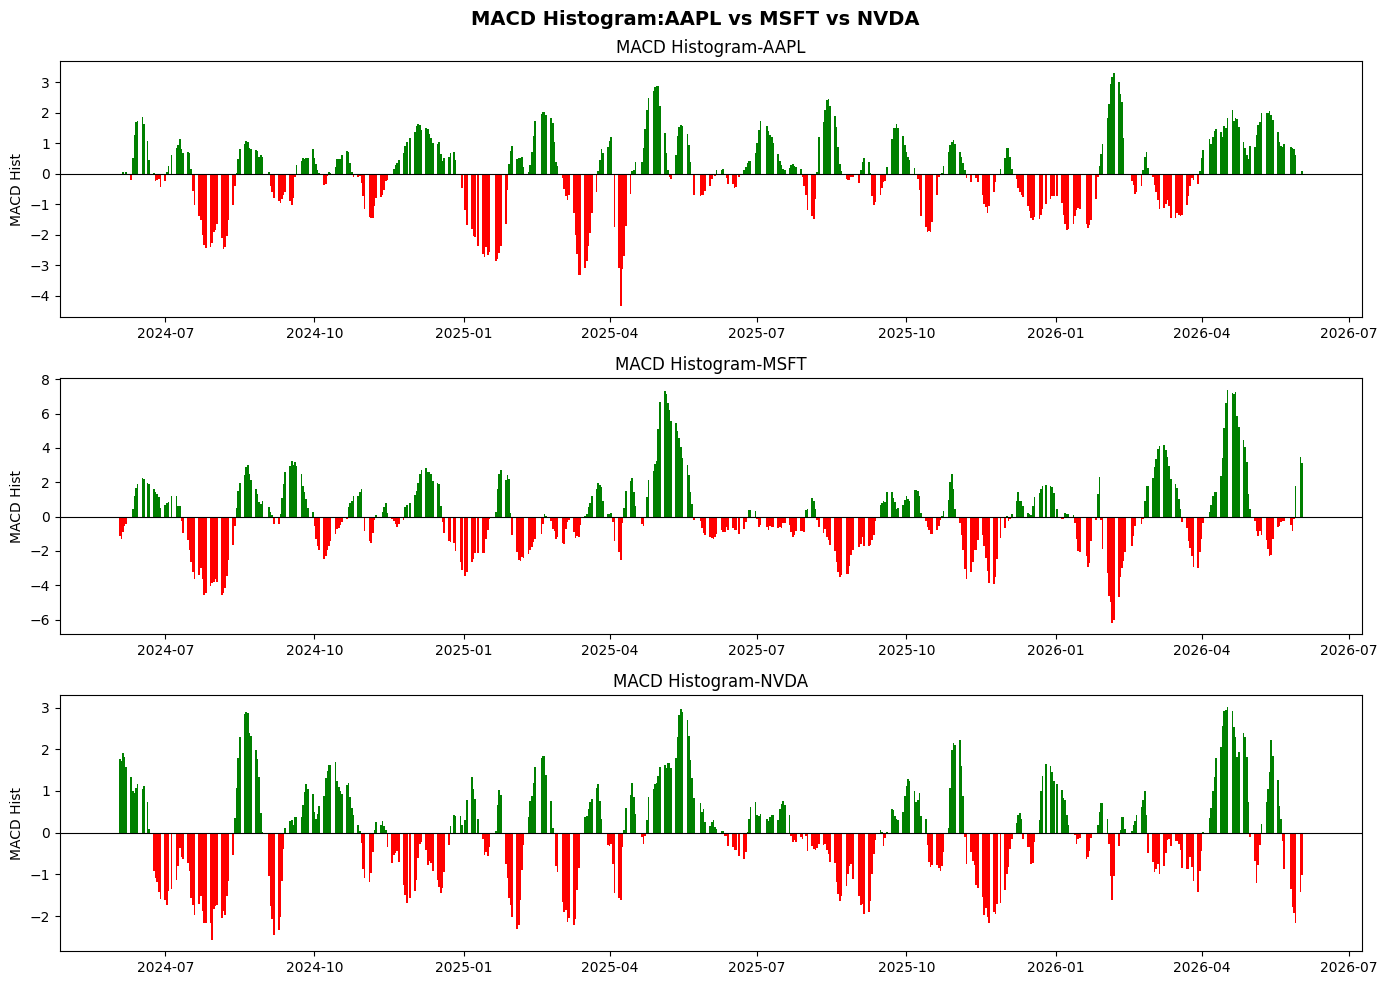

Sign changes per symbol:
AAPL:44 sign changes
MSFT:44 sign changes
NVDA:40 sign changes


In [30]:
# Your code here
symbols_q3=['AAPL','MSFT','NVDA']
colors_q3=['blue','green','orange']
fig,axes=plt.subplots(3,1,figsize=(14,10),sharex=False)
sign_changes={}
for i,(sym,color) in enumerate(zip(symbols_q3,colors_q3)):
  df=load_features(sym)
  df=df.last('730D')
  bar_colors=['green' if v>=0 else'red'
              for v in df['macd_hist']]
  axes[i].bar(df.index,df['macd_hist'],
              color=bar_colors,width=1)
  signs=np.sign(df['macd_hist'])   #Converts MACD histogram values to +1, 0, or -1:
  changes=(signs!=signs.shift(1)).sum() #Compares today's sign with yesterday's sign
  sign_changes[sym]=changes
  axes[i].set_title(f'MACD Histogram-{sym}')
  axes[i].set_ylabel('MACD Hist')
  axes[i].axhline(0,color='black',linewidth=0.8)

plt.suptitle('MACD Histogram:AAPL vs MSFT vs NVDA',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

print("Sign changes per symbol:")
for sym,count in sign_changes.items(): #sym,count-Loop 1: sym = 'AAPL', count = 44,sign_changes is a dictionary: AAPL:44,MSFT:40,NVDA:40
  print(f"{sym}:{count} sign changes")


Almost all the stocks performed equally in terms of MACD, like AAPL has changed its sign 44 times which makes it most difficukt one to invest in it during that time bcoz of its fluctuations while MSFT and NVDA changes sign almost equally .
Frequent sign changes implies stock as the less consistent.

## Q4 — Volatility comparison: which symbol has the widest Bollinger Bands on average?

Load processed features for at least **six symbols** spanning at least two markets.
Compute the **mean `bb_width`** for each symbol over its full available history.
Plot as a sorted bar chart.

Then for the **most volatile symbol**, plot its close price with Bollinger Bands and highlight the top-10% widest-band periods with a shaded background.

**Answer in a markdown cell:** What event or characteristic of that asset explains why its bands are wider than the others?

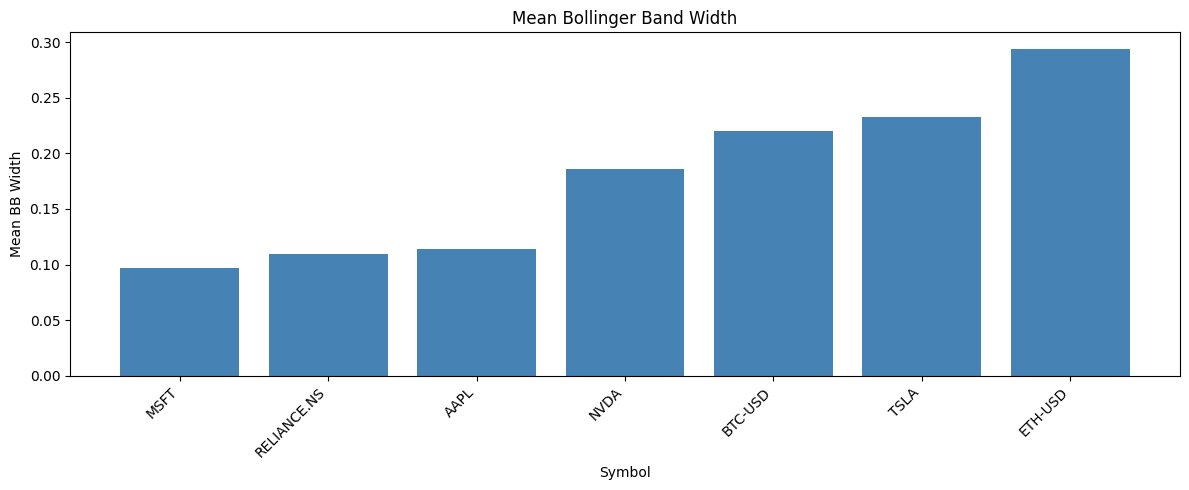

Most Volatile: ETH-USD


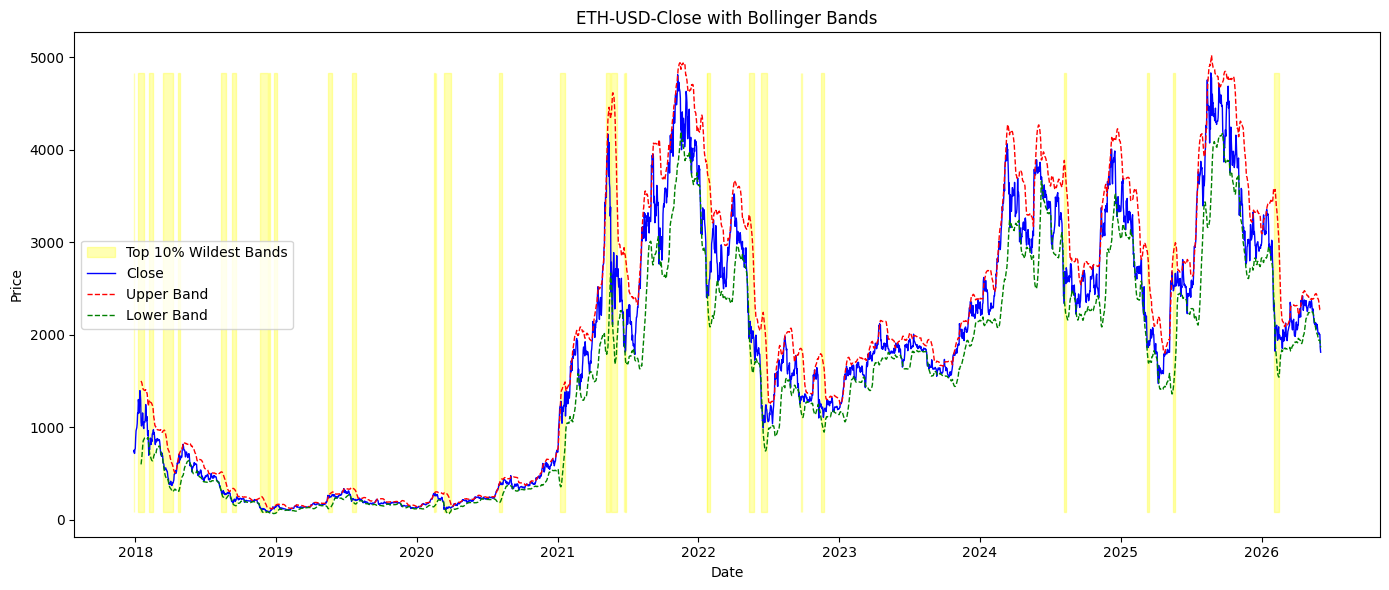

In [38]:
# Your code here
symbols_q4=['AAPL','MSFT','NVDA','TSLA','BTC-USD','ETH-USD','RELIANCE.NS']
bb_means={} #array of mean of bb_width for all symbols.
for sym in symbols_q4:
  try:
    df=load_features(sym)
    bb_means[sym]=df['bb_width'].mean()
  except:
    print(f'Skipping{sym}')

bb_series=pd.Series(bb_means).sort_values(ascending=True) #bb_means is a dictionary which is converted to bb_series(Series)
#PLOT 1
plt.figure(figsize=(12,5))
plt.bar(bb_series.index,bb_series.values,color='steelblue') #symbols-x axis,bb_means()-y axis
plt.title('Mean Bollinger Band Width')
plt.xlabel('Symbol')
plt.ylabel('Mean BB Width')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

most_volatile=bb_series.idxmax() #bb_series.idxmax()-label of max value-ETH-USD
print(f'Most Volatile: {most_volatile}')

#plot 2
df=load_features(most_volatile)
sma20 =df['close'].rolling(20).mean()
std20=df['close'].rolling(20).std()
bb_upper=sma20 +2*std20
bb_lower=sma20 -2*std20

threshold=df['bb_width'].quantile(0.90) #quantile(0.90) = find the value where 90% of data is below it
wide_band=df['bb_width']>threshold

plt.figure(figsize=(14,6))
plt.fill_between(df.index,df['close'].min(),df['close'].max(),
                 where=wide_band,  #only where top 10% wide bands
                 color='yellow',alpha=0.3,
                 label='Top 10% Wildest Bands') #Yellow = bands very wide = price moving ALOT = big news happened
plt.plot(df.index,df['close'],
         label='Close',color='blue',linewidth=1)
plt.plot(df.index,bb_upper,
         label='Upper Band',color='red',linewidth=1,linestyle='--') #Red LiNE Moves above price during uptrends, When price touches red line → overbought!

plt.plot(df.index,bb_lower,
         label='Lower Band',color='green',
         linestyle='--',linewidth=1) #Green Line Moves below price during downtrends, When price touches green line → oversold!
plt.title(f'{most_volatile}-Close with Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


In the first plot , i have plotted mean band width vs stocks ,in which ETH-USD has the maximum value, so it can be known from that histogram that maximum voatility is of ETH-USD ,so it is the msot risky stock while MSFT is the least risky stoc as compared to others which indicates it is consisitent with least band width mean value which further indicates low volatitlity.
In the second graph, dates are on x axis while price is on y axis, graph is of ETH-USD(max volatile),yellow lines are indicating band is very wide, it is very risky to invest in this period of 2020-2021 and then midway between 2033-2023 and also when close rice moves above red line it indicates that the stock is overbrought and when green line moves below close price,it indicates stock is oversold.


## Q5 — Why was RSI elevated? (Three companies, written analysis)

Choose **three companies** — one from each market group (India / US / Crypto).

For each company, find the **longest consecutive streak of days with `rsi_14` > 0.65**.
Report: start date, end date, streak length in days, and the price gain (%) during that streak.

For each company, write **at least 3 sentences** explaining what likely drove the sustained momentum. Consider: earnings releases, macro tailwinds, sector rotation, or broader market risk-on periods. Use the dates you found to anchor your reasoning.

Plot the price and RSI together for each company, with the identified streak highlighted.

India-RELIANCE.NS
Start:2017-07-05
End:2017-08-04
Length:23days
Gain:13.34%
US-AAPL
Start:2017-01-06
End:2017-04-06
Length:63days
Gain:22.37%
Crypto-BTC-USD
Start:2020-10-19
End:2020-11-25
Length:38days
Gain:59.53%


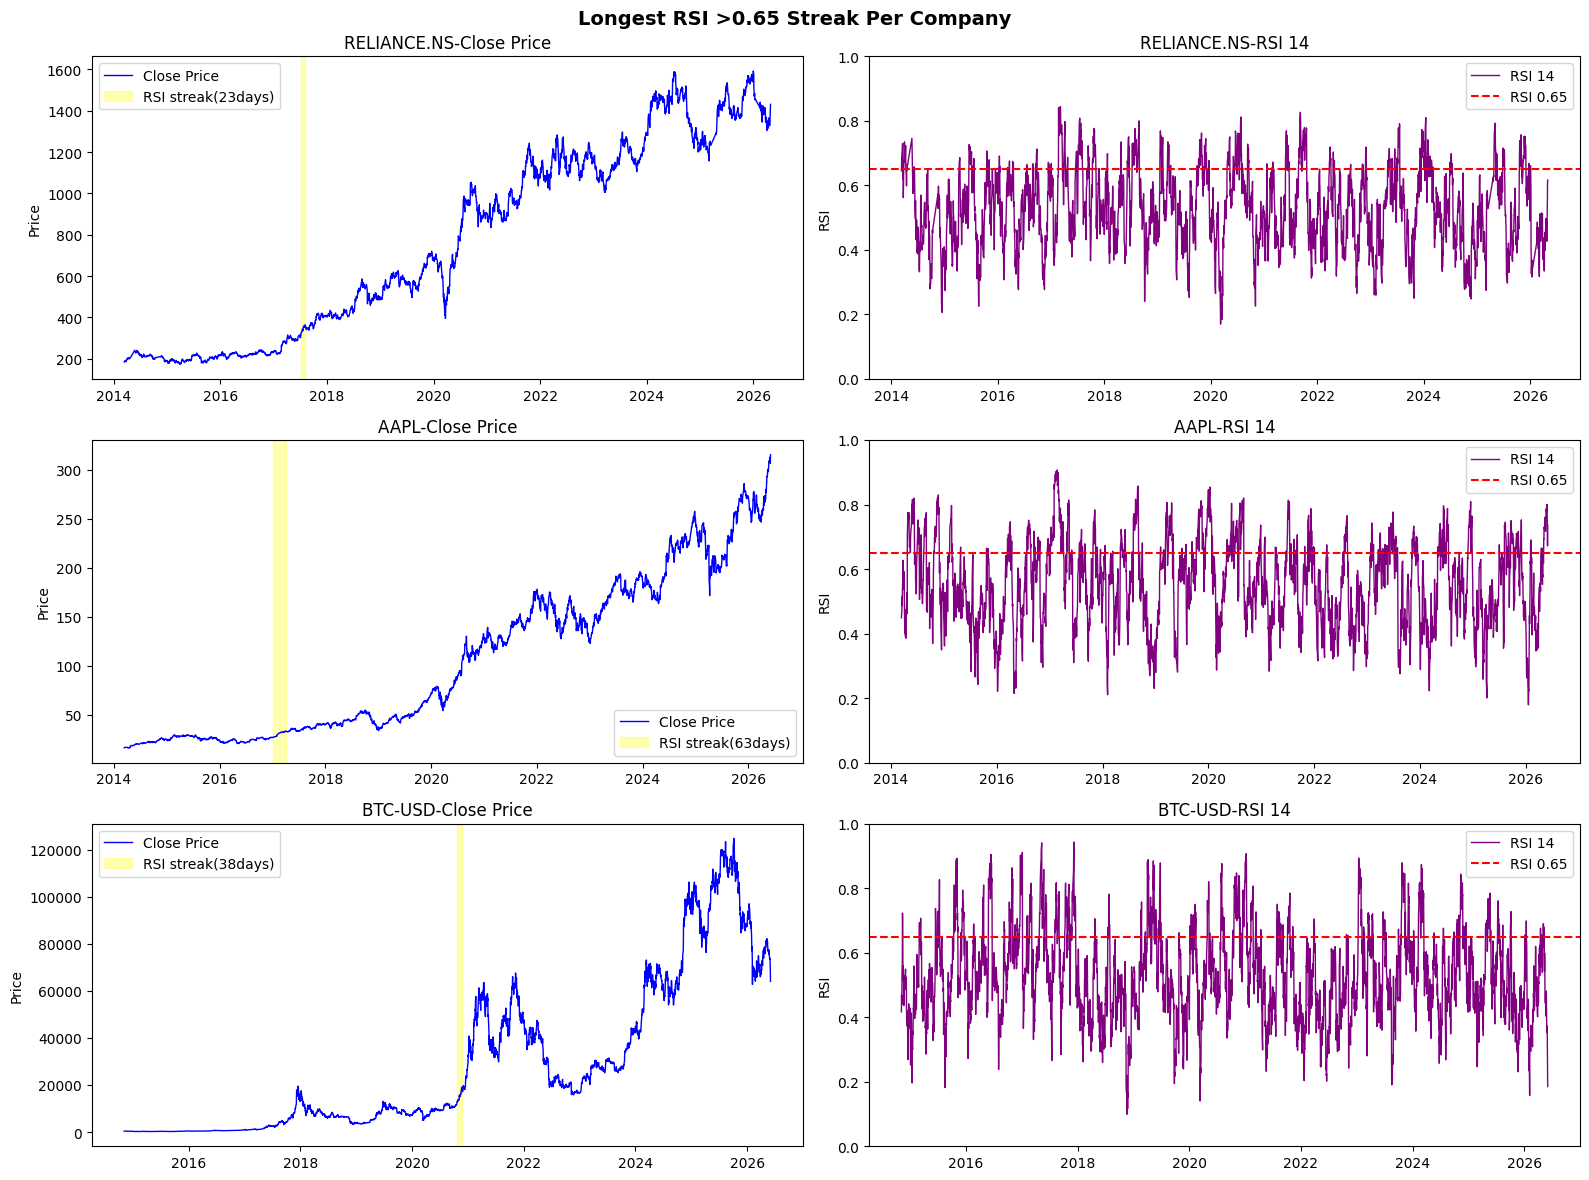

In [51]:
# Your code here — find longest overbought streak per company
companies={
    'India':'RELIANCE.NS',
    'US':'AAPL',
    'Crypto':'BTC-USD'
}
fig,axes=plt.subplots(len(companies),2,figsize=(16,12))
for idx,(market,sym) in enumerate (companies.items()):
  df=load_features(sym)

  rsi_high=df['rsi_14']>0.65
  streak_id=(rsi_high!=rsi_high.shift()).cumsum() #rsi_high.shift() → yesterday's value,rsi_high != rsi_high.shift() → did it change?,.cumsum() → running total of changes

  true_streaks=streak_id[rsi_high]  #Only streak IDs where RSI was above 0.65
  streak_counts=true_streaks.value_counts() #Counts how many days each streak has
  longest_id=streak_counts.idxmax() #Finds streak ID with MOST days

  streak_mask=(streak_id==longest_id)& rsi_high #rows belonging to longest streak & rows where RSI > 0.65
  streak_dates=df.index[streak_mask] #Gets actual DATES of longest streak

  start_date=streak_dates[0]
  end_date=streak_dates[-1]
  streak_len=len(streak_dates)

  price_start=df.loc[start_date,'close']
  price_end=df.loc[end_date,'close']
  price_gain=(price_end/price_start-1)*100

  print(f'{market}-{sym}')
  print(f'Start:{start_date.date()}')
  print(f'End:{end_date.date()}')
  print(f'Length:{streak_len}days')
  print(f'Gain:{price_gain:.2f}%')

  #PLOT 1
  axes[idx,0].plot(df.index,df['close'],color='blue',linewidth=1,label='Close Price')
  axes[idx,0].axvspan(start_date,end_date,color='yellow',alpha=0.3,label=f'RSI streak({streak_len}days)')
  axes[idx,0].set_title(f'{sym}-Close Price')
  axes[idx,0].set_ylabel('Price')
  axes[idx,0].legend()

  #PLOT 2
  axes[idx,1].plot(df.index,df['rsi_14'],color='purple',linewidth=1,label='RSI 14')
  axes[idx,1].axhline(0.65,color='red',linestyle='--',label='RSI 0.65')
  axes[idx,1].set_title(f'{sym}-RSI 14')
  axes[idx,1].set_ylabel('RSI')
  axes[idx,1].set_ylim(0,1)
  axes[idx,1].legend()

plt.suptitle ('Longest RSI >0.65 Streak Per Company', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()





*Company A (India) — written answer:RELIANCE(INDIA) has longest RSI streak of 23 days around 2017-18. Price was around 400-600 rs at that time and after streak price has increased upto rs 1600 =streak predicted the uptrend in this case. In second graph,RSI frequently crosses 0.65 which indicates reguar momemtum period.*

*Company B (US) — written answer: AAPL from US has the longest streak among the three of 63 days around 2017-18 ,price was around $40-50 during streak which increased further upto $300 followed by massive uptrend. Right graph highlights strong buying momemtum period. *

*Company C (Crypto) — written answer: Streak was around 38 days here. Price was around $10,1000 during the streak and after streak price went upto $120,000. Right graph highlights  strong buying momemtum.
*

---

## Q6 — Why was ATR ratio highest in that month? (Three companies)

Using the same three companies from Q5:

For each company, find the **calendar month with the highest mean `atr_ratio`**.
Plot the daily `atr_ratio` for the full year containing that month, with the peak month highlighted using `fill_between` or `axvspan`.

Write **at least 3 sentences per company** explaining the spike. Consider: earnings surprises, central bank decisions, geopolitical events, or crypto-specific catalysts. ATR captures both intraday swings and overnight gap risk — comment on which you think dominated.

India-RELIANCE.NS
Peak Month:April 2020
Mean ATR Ratio:0.0634
US-AAPL
Peak Month:March 2020
Mean ATR Ratio:0.0596
Crypto-BTC-USD
Peak Month:February 2018
Mean ATR Ratio:0.1209


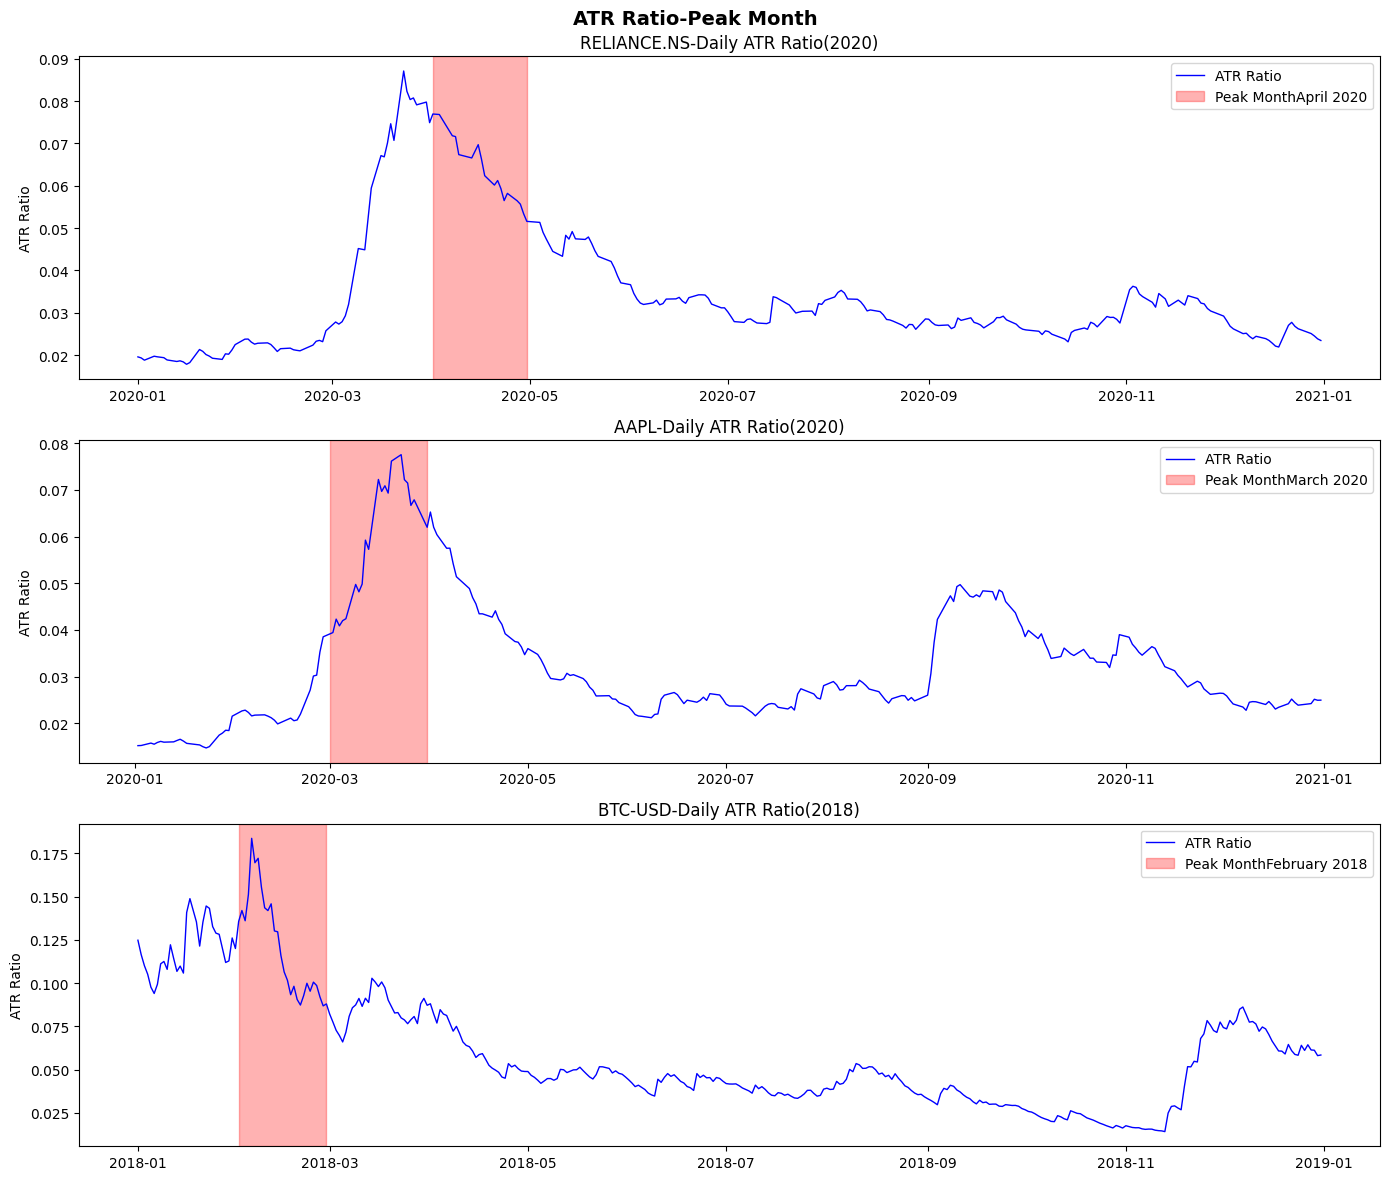

In [44]:
# Your code here
companies={
    'India':'RELIANCE.NS',
    'US':'AAPL',
    'Crypto':'BTC-USD'
}

fig,axes=plt.subplots(len(companies),1,figsize=(14,12),sharex=False)
for idx,(market,sym) in enumerate(companies.items()): #idx=0,1,2,market-country,sym-symbol
  df=load_features(sym)

  monthly_atr=df['atr_ratio'].resample('ME').mean()  #resample('ME') → Jan 2020 → average of all Jan 2020 days
  peak_month=monthly_atr.idxmax()
  peak_year=peak_month.year #year of peak_month

  year_data=df[df.index.year==peak_year] #keep only rows from 2020
  month_start=peak_month.replace(day=1) #atr_ratio mean is always mentioned at end of month,so replace that day with 1st day of month, otherwise only last date will be taken into consideration except for the whole month, without replace of last day with first day-month_start = peak_month = 2020-03-31 month_end = peak_month = 2020-03-31
  month_end=peak_month

  print(f'{market}-{sym}')
  print(f'Peak Month:{peak_month.strftime('%B %Y')}') # strftime-Converts a date into a readable string.(datetime format)
  print(f'Mean ATR Ratio:{monthly_atr[peak_month]:.4f}')

  axes[idx].plot(year_data.index,year_data['atr_ratio'],color='blue',linewidth=1,label='ATR Ratio')
  axes[idx].axvspan(month_start,month_end,color='red',alpha=0.3,label=f'Peak Month{peak_month.strftime('%B %Y')}') #axvspan = vertical span = shaded rectangle
  axes[idx].set_title(f'{sym}-Daily ATR Ratio({peak_year})')
  axes[idx].set_ylabel('ATR Ratio')
  axes[idx].legend()
plt.suptitle('ATR Ratio-Peak Month',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()



*Company A — written answer: So, in India, i have used reliance, so peak month is april 2020, so it signifies stock is volatile in that period. It means the stock was mobing 6.34% per day on avg of april 2020. The stock opening is different from yesterday close in that period on regular basis.*

*Company B — written answer:In US, AAPL is taken and peak month is march 2020. In that period, 5.96% is the rate with which stock is fluctuating on avg during that cycle. Same like of RELIANCE at that time almost.Only the month is different.*

*Company C — written answer: In CRYPTO, BTC-USD is taken  and peak is feb 2018. So market fluctuated at a daily rate of 12% almost which is very high on regular basis which is very high during that period. It means stock prices are very much volatile during that period.*

---

## Q7 — Does a high Stochastic %K always mean the stock is overbought?

Compute the fraction of days with `stoch_k` > 0.80 for each of your three companies.
Bar-chart the results.

Then for the company with the **highest fraction**, plot its `stoch_k` alongside `sma_ratio_50` for the last two years on a dual-panel chart.

**Answer in a markdown cell:** A high stochastic can mean (a) the stock is genuinely overbought and due for reversal, or (b) it is in a strong uptrend and keeps closing near its highs. Use the `sma_ratio_50` panel to argue which case applies here.

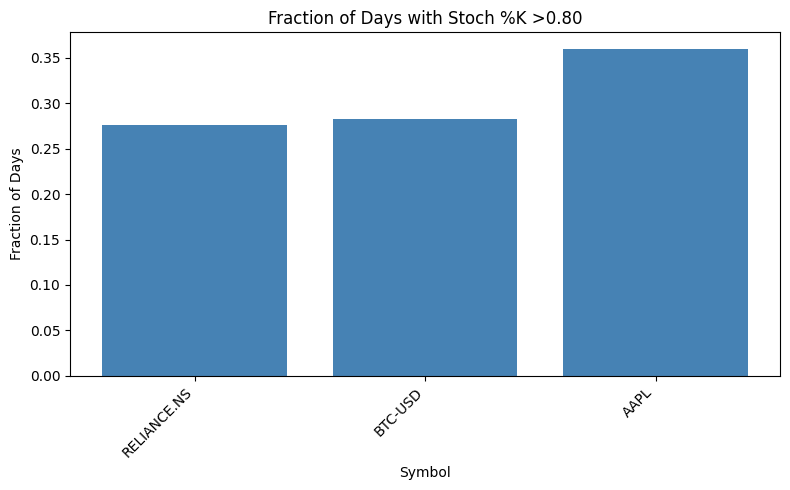

Fraction of days stoch_k>0.8
RELIANCE.NS    0.276194
BTC-USD        0.283046
AAPL           0.360234
dtype: float64
Highest Fraction:AAPL


/tmp/ipykernel_6191/2906848581.py:31: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent=df.last('730D')


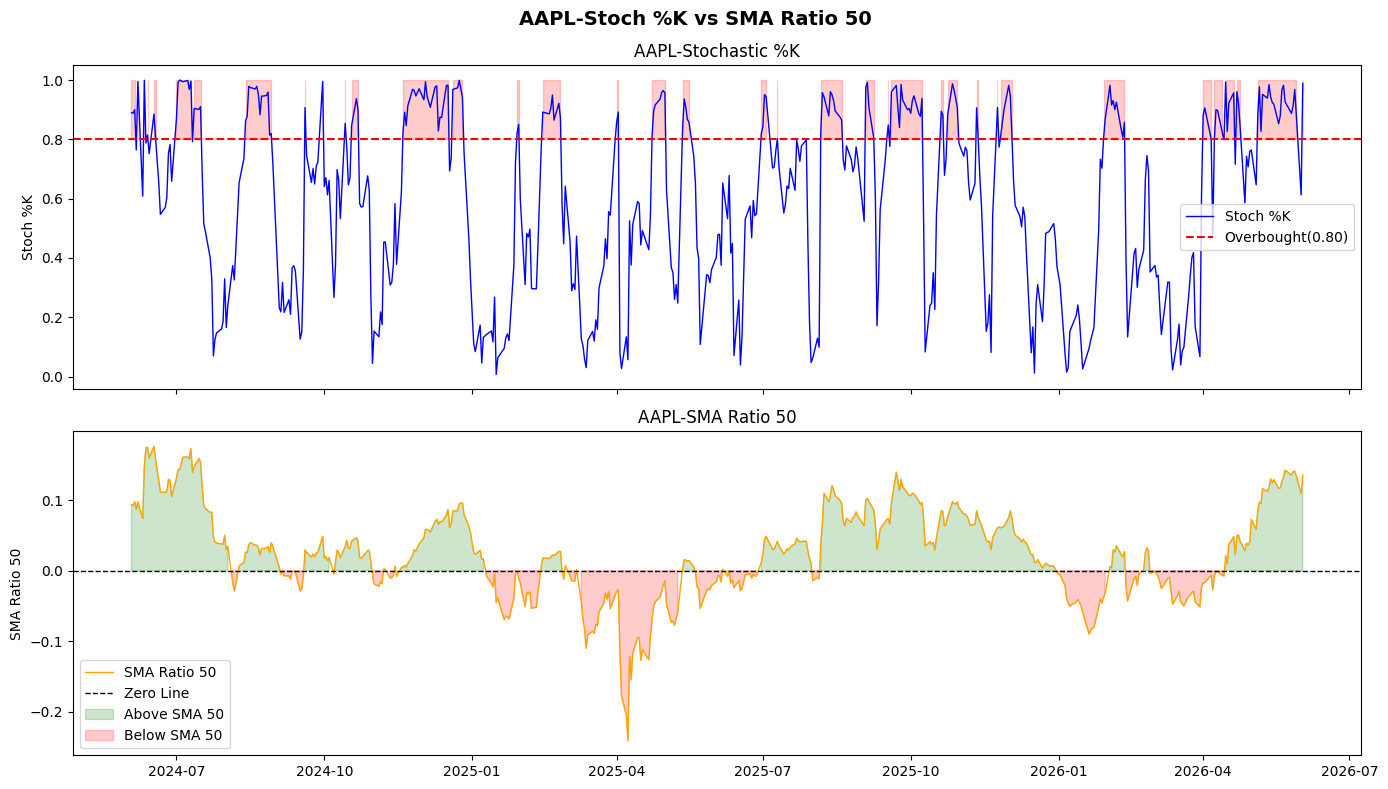

In [48]:
# Your code here
companies={
    'India':'RELIANCE.NS',
    'US':'AAPL',
    'Crypto':'BTC-USD'
}
fractions={}
for market,sym in companies.items():
  df=load_features(sym)
  fractions[sym]=(df['stoch_k']>0.80).mean()

frac_series=pd.Series(fractions).sort_values(ascending=True)

plt.figure(figsize=(8,5))
plt.bar(frac_series.index,frac_series.values,color='steelblue')
plt.title('Fraction of Days with Stoch %K >0.80')
plt.xlabel('Symbol')
plt.ylabel('Fraction of Days')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

print("Fraction of days stoch_k>0.8")
print(frac_series)

highest_sym=frac_series.idxmax()
print(f"Highest Fraction:{highest_sym}")

#dual panel chart
df=load_features(highest_sym)
recent=df.last('730D')
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,8),sharex=True)
#Panel 1-Stochastic %K
ax1.plot(recent.index,recent['stoch_k'],color='blue',linewidth=1,label='Stoch %K')
ax1.axhline(0.80,color='red',linestyle='--',label='Overbought(0.80)') #Stock closing near 14-day HIGH → Could mean: (a) Overbought → due for reversal  (b) Strong uptrend → keep going up
ax1.fill_between(recent.index,0.80,1.0,where=recent['stoch_k']>0.80,color='red',alpha=0.2)
ax1.set_title(f'{highest_sym}-Stochastic %K')
ax1.set_ylabel('Stoch %K')
ax1.legend()
#Panel 2-SMA Ratio 50
ax2.plot(recent.index,recent['sma_ratio_50'],color='orange',linewidth=1,label='SMA Ratio 50')
ax2.axhline(0,color='black',linestyle='--',linewidth=1,label='Zero Line')
ax2.fill_between(recent.index,0,recent['sma_ratio_50'],where=recent['sma_ratio_50']>0,color='green',alpha=0.2,label='Above SMA 50')
ax2.fill_between(recent.index,0,recent['sma_ratio_50'],where=recent['sma_ratio_50']<0,color='red',alpha=0.2,label='Below SMA 50')
ax2.set_title(f'{highest_sym}-SMA Ratio 50')
ax2.set_ylabel('SMA Ratio 50')
ax2.legend()

plt.suptitle(f'{highest_sym}-Stoch %K vs SMA Ratio 50',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


AAPL has the highest fraction of all these 3 stocks in stoch_k>0.8 avg. On y axis we ahve stoch_k>0.8 mean. And fro that t is evident that AAPL holds highest among three which means stock closing prices are always on a good note for AAPL.
Then stoch_k plot is there in which AAPL is highlighted that above 0.8 its stock has gone multiple times in recent 2 years of data. And in next plot the sma ratio 50 is highlighted where some times closing price on that particular day is higher than avg of last 50 days which indicates above 0 and also sometimes it is below 0.
#>0.80,> 0,Strong uptrend,HOLD/BUY
#> 0.80,< 0,Short spike only,SELL soon
#< 0.20,< 0,Strong downtrend,AVOID
#< 0.20,> 0,Short dip only,BUY opportunity